# ODI Bowling EDA

### 1. **Import required libraries**

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

### 2. **Load ODI Batting Dataset**

In [3]:
df = pd.read_csv(r"C:\Users\shiv_\OneDrive\Desktop\Cricket Analytics & Player Performance Intelligence Dashboard\Data\Processed\Bowling_ODI_Cleaned.csv")
df.head(10)

,Player,Span,Start_Year,End_Year,Career_Length,Mat,Inns,Balls,Runs,Wkts,BBI,Ave,Econ,SR,4,5,Wickets_Per_Match,Economy_Score,Bowling_Impact_Score,Five_Wicket_Rate
0,M Muralitharan (Asia/ICC/SL),1993-2011,1993,2011,18,350,341,18811,12326,534,Jul-30,23.08,3.93,35.2,15,10,1.53,0.25,1.14,0.029
1,Wasim Akram (PAK),1984-2003,1984,2003,19,356,351,18186,11812,502,May-15,23.52,3.89,36.2,17,6,1.41,0.26,1.06,0.017
2,Waqar Younis (PAK),1989-2003,1989,2003,14,262,258,12698,9919,416,Jul-36,23.84,4.68,30.5,14,13,1.59,0.21,1.18,0.050
3,WPUJC Vaas (Asia/SL),1994-2008,1994,2008,14,322,320,15775,11014,400,Aug-19,27.53,4.18,39.4,9,4,1.24,0.24,0.94,0.012
4,Shahid Afridi (Asia/ICC/PAK),1996-2015,1996,2015,19,398,372,17670,13632,395,07-Dec,34.51,4.62,44.7,4,9,0.99,0.22,0.76,0.023
5,SM Pollock (Afr/ICC/SA),1996-2008,1996,2008,12,303,297,15712,9631,393,Jun-35,24.5,3.67,39.9,12,5,1.30,0.27,0.99,0.017
6,GD McGrath (AUS/ICC),1993-2007,1993,2007,14,250,248,12970,8391,381,Jul-15,22.02,3.88,34,9,7,1.52,0.26,1.14,0.028
7,B Lee (AUS),2000-2012,2000,2012,12,221,217,11185,8877,380,May-22,23.36,4.76,29.4,14,9,1.72,0.21,1.27,0.041
8,SL Malinga (SL),2004-2019,2004,2019,15,226,220,10936,9760,338,Jun-38,28.87,5.35,32.3,11,8,1.50,0.19,1.10,0.035
9,A Kumble (Asia/INDIA),1990-2007,1990,2007,17,271,265,14496,10412,337,06-Dec,30.89,4.3,43,8,2,1.24,0.23,0.94,0.007


### 3. **Dataset Summary**

In [4]:
print(df.shape)
print(df.info())
print(df.describe())

(2582, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2582 entries, 0 to 2581
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Player                2582 non-null   object
 1   Span                  2582 non-null   object
 2   Start_Year            2582 non-null   int64 
 3   End_Year              2582 non-null   int64 
 4   Career_Length         2582 non-null   int64 
 5   Mat                   2582 non-null   int64 
 6   Inns                  2582 non-null   object
 7   Balls                 2582 non-null   object
 8   Runs                  2582 non-null   object
 9   Wkts                  2582 non-null   object
 10  BBI                   2582 non-null   object
 11  Ave                   2582 non-null   object
 12  Econ                  2582 non-null   object
 13  SR                    2582 non-null   object
 14  4                     2582 non-null   object
 15  5                     2582 

In [8]:
corr_cols = ['Inns','Balls','Runs','Wkts','BBI','Ave','Econ', 'SR','4','5','Wickets_Per_Match','Economy_Score','Bowling_Impact_Score','Five_Wicket_Rate']
for col in corr_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
for i in corr_cols:
    df[i] = pd.to_numeric(df[i], errors='coerce').fillna(0)

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2582 entries, 0 to 2581
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Player                2582 non-null   object 
 1   Span                  2582 non-null   object 
 2   Start_Year            2582 non-null   int64  
 3   End_Year              2582 non-null   int64  
 4   Career_Length         2582 non-null   int64  
 5   Mat                   2582 non-null   int64  
 6   Inns                  2582 non-null   float64
 7   Balls                 2582 non-null   float64
 8   Runs                  2582 non-null   float64
 9   Wkts                  2582 non-null   float64
 10  BBI                   2582 non-null   float64
 11  Ave                   2582 non-null   float64
 12  Econ                  2582 non-null   float64
 13  SR                    2582 non-null   float64
 14  4                     2582 non-null   float64
 15  5                    

### 4. **Visualizations**

##### 1. **Top 10 Wicket Takers**

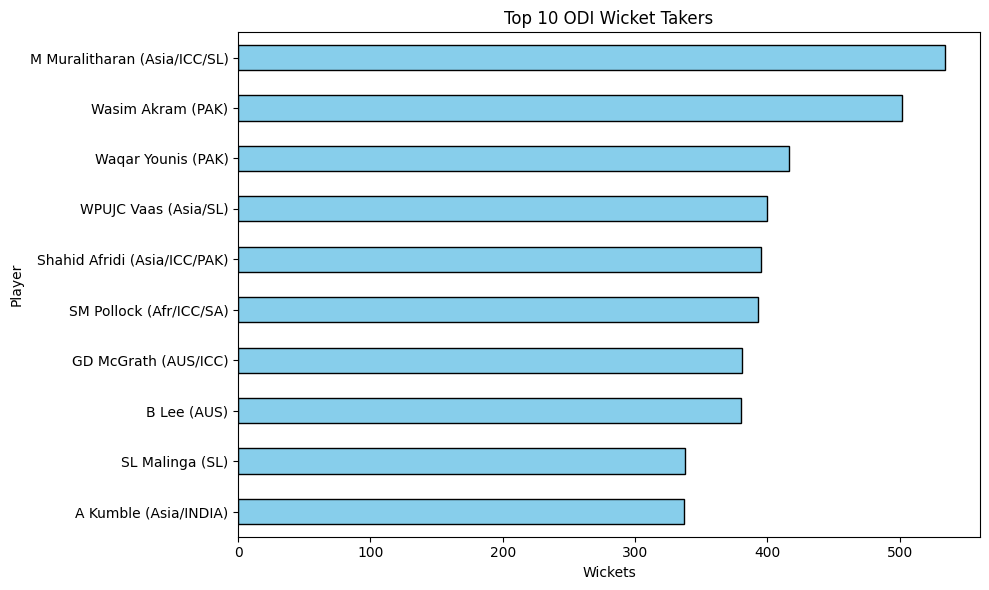

In [10]:
top_runs = (df.groupby('Player')['Wkts'].sum().sort_values(ascending=True).tail(10))

fig, ax = plt.subplots(figsize=(10,6))

top_runs.plot(kind='barh',ax=ax, color='skyblue', edgecolor='black')

plt.title('Top 10 ODI Wicket Takers')
plt.xlabel('Wickets')
plt.ylabel('Player')

plt.tight_layout()
plt.savefig(r'../Images/Top_10_ODI_Wicket_Takers.png',dpi=300,bbox_inches='tight')
plt.show()

**Insight:** 

##### 2. **Best Bowling Average (Minimum 50 Matches)**

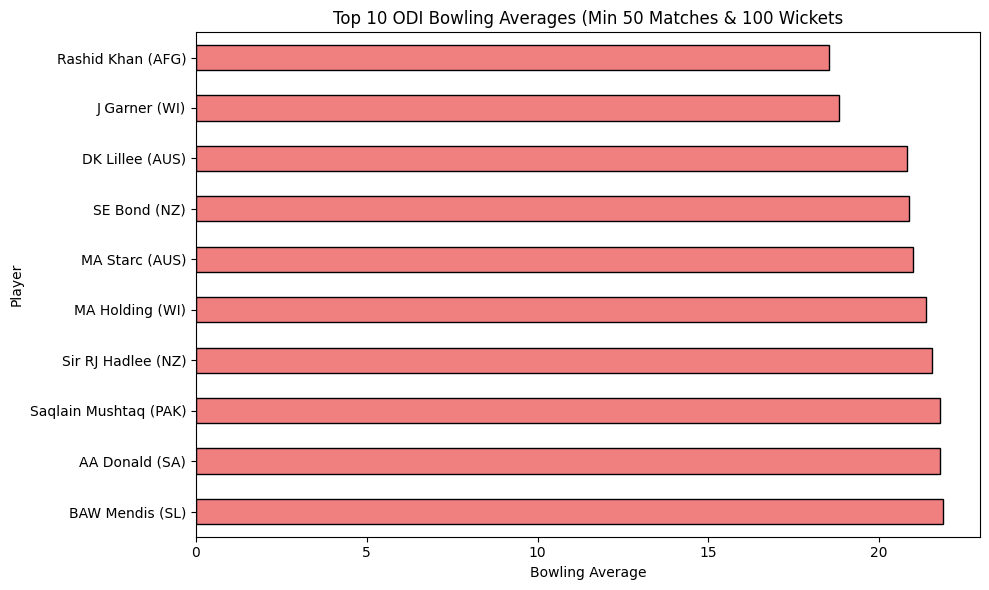

In [20]:
df_filtered = df[
    (df['Mat'] >= 50) &
    (df['Wkts'] >= 100)
]
top_avg = (df_filtered.sort_values(by='Ave', ascending=True).head(10).set_index('Player')['Ave'])

fig, ax = plt.subplots(figsize=(10,6))
top_avg.sort_values(ascending=False).plot(kind='barh',ax=ax,color='lightcoral',edgecolor='black')

plt.title('Top 10 ODI Bowling Averages (Min 50 Matches & 100 Wickets')
plt.xlabel('Bowling Average')
plt.ylabel('Player')

plt.tight_layout()
plt.savefig(
    r'../Images/Top_10_Best_ODI_Bowling_Averages.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()